# K-Nearest Neighbors (KNN) Algorithm

KNN is a **non-parametric, instance-based supervised learning** algorithm used for classification and regression. It makes predictions by identifying the *K* most similar training examples to a new input and aggregating their labels — no explicit training phase, no model parameters.

---

## Core Concepts

| Concept | Definition |
|---------|-----------|
| **Distance metric** | A function quantifying similarity between two data points (e.g., Euclidean, Manhattan) |
| **K (number of neighbors)** | Hyperparameter controlling how many neighbors participate in the vote |
| **Majority voting** | The predicted class is the most frequent label among the K nearest neighbors |
| **Lazy learner** | No training step; computation is deferred entirely to prediction time |

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain how KNN makes predictions using distance and voting
2. Compute Euclidean distance manually and programmatically
3. Visualize the effect of choosing different values of K
4. Identify the trade-offs between small and large K values

## Section 1 — Environment Setup

Install and import all required libraries. A fixed random seed is set to ensure reproducibility across runs.

In [9]:
%pip install -q numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# Styling
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 12,
})

# Reproducibility
np.random.seed(42)

# Generate 2D dataset with 2 classes
X, y = make_classification(
    n_samples=40,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

print("✅ Libraries imported and dataset generated!")
print(f"   Dataset shape: {X.shape} | Classes: {np.unique(y)}")
print(f"   Class 0 (Red): {np.sum(y==0)} points | Class 1 (Blue): {np.sum(y==1)} points")

✅ Libraries imported and dataset generated!
   Dataset shape: (40, 2) | Classes: [0 1]
   Class 0 (Red): 19 points | Class 1 (Blue): 21 points


## Section 2 — Dataset Visualization

Before applying any algorithm, it is important to understand the structure of the data. The scatter plot below shows the two-class distribution across two continuous features.

- **Class 0** — plotted in red
- **Class 1** — plotted in blue

Observe whether the classes are linearly separable and how much overlap exists between them.

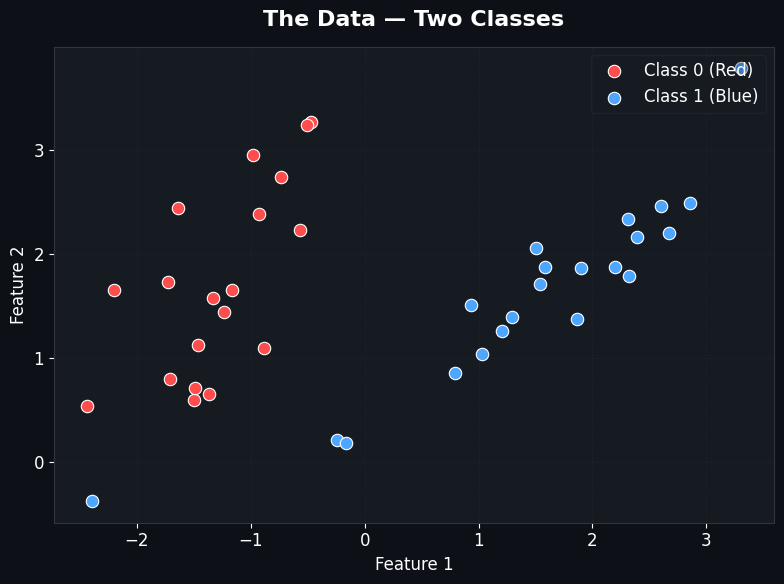

📌 Two clearly separable clusters — red and blue!


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Class 0 (Red) and Class 1 (Blue)
ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=80, edgecolors='white',
           linewidths=0.8, label='Class 0 (Red)', zorder=3)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=80, edgecolors='white',
           linewidths=0.8, label='Class 1 (Blue)', zorder=3)

ax.set_title('The Data — Two Classes', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='upper right', framealpha=0.3, edgecolor='#30363d')
ax.grid(True)

plt.tight_layout()
plt.show()
print("📌 Two clearly separable clusters — red and blue!")

## Section 3 — Introducing a Query Point

A **query point** (also called a test point) is a new, unlabeled data sample whose class we want to predict. It is plotted as a green star to distinguish it from the labeled training data.

The goal of KNN is to assign a class label to this point based solely on the labels of its nearest neighbors in the training set.

/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/1888361931.py:24: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/nilesh/Desktop/untitled folder 6/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


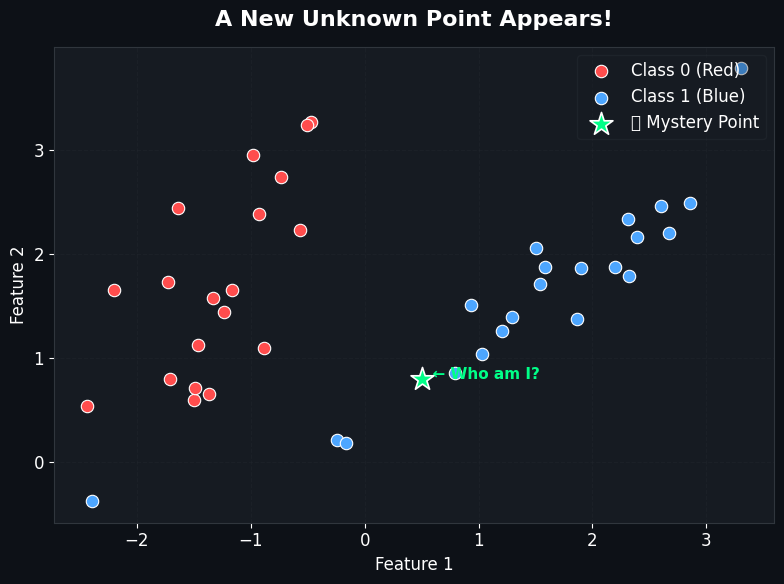

🌟 Mystery point coordinates: [0.5 0.8]


In [12]:
# Define the mystery point (unknown class)
new_point = np.array([0.5, 0.8])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=80, edgecolors='white',
           linewidths=0.8, label='Class 0 (Red)', zorder=3)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=80, edgecolors='white',
           linewidths=0.8, label='Class 1 (Blue)', zorder=3)

# Plot mystery point as green star
ax.scatter(*new_point, c='#00ff88', s=300, marker='*', edgecolors='white',
           linewidths=1.2, label='❓ Mystery Point', zorder=5)

ax.annotate('  ← Who am I?', xy=new_point, fontsize=11,
            color='#00ff88', fontweight='bold')

ax.set_title('A New Unknown Point Appears!', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='upper right', framealpha=0.3, edgecolor='#30363d')
ax.grid(True)

plt.tight_layout()
plt.show()
print(f"🌟 Mystery point coordinates: {new_point}")

## Section 4 — Distance Calculation

KNN relies on a **distance metric** to rank training points by proximity to the query point. The most commonly used metric is **Euclidean distance**:

$$d(p, q) = \sqrt{\sum_{i=1}^{n}(q_i - p_i)^2}$$

For two-dimensional data this simplifies to:

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

A smaller distance indicates a more similar (closer) neighbor. The table below ranks all training points by their distance from the query point.

In [13]:
def euclidean_distance(p1, p2):
    """Compute Euclidean distance between two 2D points."""
    return np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)

# Compute distances from mystery point to all training points
distances = np.array([euclidean_distance(new_point, X[i]) for i in range(len(X))])

# Sort by distance
sorted_idx = np.argsort(distances)
sorted_distances = distances[sorted_idx]
sorted_classes = y[sorted_idx]

# Display top 10 closest neighbors
print("┌─────┬──────────────────────────┬────────────┬─────────┐")
print("│ Rank│ Point Coords             │ Distance   │ Class   │")
print("├─────┼──────────────────────────┼────────────┼─────────┤")
for rank, idx in enumerate(sorted_idx[:10], 1):
    cls_label = "🔴 Red (0)" if y[idx] == 0 else "🔵 Blue (1)"
    print(f"│ {rank:<3} │ ({X[idx,0]:+.3f}, {X[idx,1]:+.3f})    │ {distances[idx]:.4f}     │ {cls_label} │")
print("└─────┴──────────────────────────┴────────────┴─────────┘")

┌─────┬──────────────────────────┬────────────┬─────────┐
│ Rank│ Point Coords             │ Distance   │ Class   │
├─────┼──────────────────────────┼────────────┼─────────┤
│ 1   │ (+0.794, +0.857)    │ 0.2991     │ 🔵 Blue (1) │
│ 2   │ (+1.033, +1.043)    │ 0.5856     │ 🔵 Blue (1) │
│ 3   │ (+0.937, +1.512)    │ 0.8359     │ 🔵 Blue (1) │
│ 4   │ (+1.206, +1.257)    │ 0.8412     │ 🔵 Blue (1) │
│ 5   │ (-0.160, +0.181)    │ 0.9048     │ 🔵 Blue (1) │
│ 6   │ (-0.247, +0.213)    │ 0.9498     │ 🔵 Blue (1) │
│ 7   │ (+1.290, +1.393)    │ 0.9876     │ 🔵 Blue (1) │
│ 8   │ (+1.542, +1.710)    │ 1.3835     │ 🔵 Blue (1) │
│ 9   │ (-0.886, +1.094)    │ 1.4167     │ 🔴 Red (0) │
│ 10  │ (+1.867, +1.375)    │ 1.4830     │ 🔵 Blue (1) │
└─────┴──────────────────────────┴────────────┴─────────┘


## Section 5 — Selecting the K Nearest Neighbors (K = 5)

With K = 5, the algorithm selects the **5 training points closest** to the query point. These neighbors are highlighted with gold circles, and dashed lines connect them to the query point.

The gold circle boundary represents the **search radius** — the maximum distance at which a point qualifies as a neighbor. Only points within this circle participate in the classification vote.

/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/2101167799.py:40: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


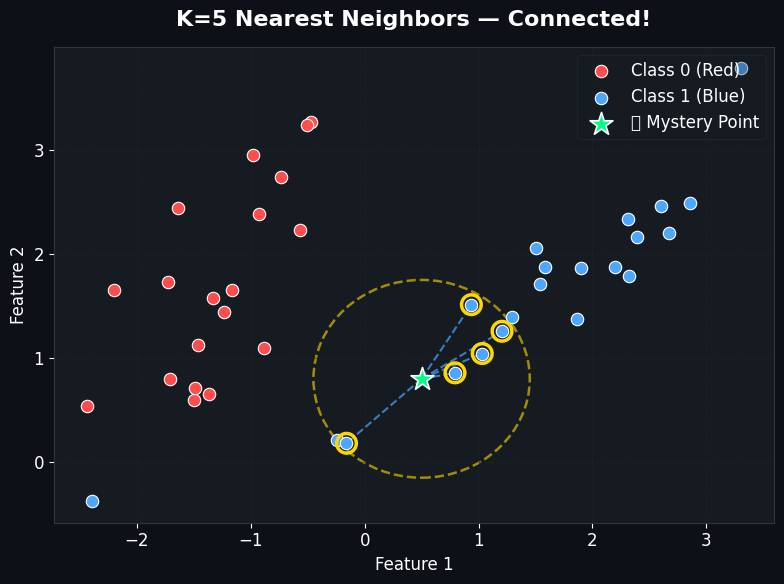

🎯 The 5 nearest neighbors:
   Neighbor 1: dist=0.299 → 🔵 Blue (1)
   Neighbor 2: dist=0.586 → 🔵 Blue (1)
   Neighbor 3: dist=0.836 → 🔵 Blue (1)
   Neighbor 4: dist=0.841 → 🔵 Blue (1)
   Neighbor 5: dist=0.905 → 🔵 Blue (1)


In [14]:
K = 5
k_nearest_idx = sorted_idx[:K]
k_nearest_points = X[k_nearest_idx]
k_nearest_classes = y[k_nearest_idx]

# Radius of the circle = distance to the K-th neighbor
k_radius = distances[k_nearest_idx[-1]] * 1.05

fig, ax = plt.subplots(figsize=(8, 6))

# All data points
ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=80, edgecolors='white',
           linewidths=0.8, label='Class 0 (Red)', zorder=3)
ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=80, edgecolors='white',
           linewidths=0.8, label='Class 1 (Blue)', zorder=3)

# Mystery point
ax.scatter(*new_point, c='#00ff88', s=300, marker='*', edgecolors='white',
           linewidths=1.2, label='❓ Mystery Point', zorder=5)

# Draw lines to K nearest neighbors
for i, pt in enumerate(k_nearest_points):
    color = '#ff4d4d' if k_nearest_classes[i] == 0 else '#4da6ff'
    ax.plot([new_point[0], pt[0]], [new_point[1], pt[1]],
            color=color, lw=1.5, alpha=0.7, linestyle='--', zorder=2)
    ax.scatter(*pt, s=200, facecolors='none', edgecolors='#ffd700',
               linewidths=2.5, zorder=4)

# Draw circle boundary
circle = plt.Circle(new_point, k_radius, color='#ffd700', fill=False,
                    linestyle='--', linewidth=1.8, alpha=0.6)
ax.add_patch(circle)

ax.set_title(f'K={K} Nearest Neighbors — Connected!', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(loc='upper right', framealpha=0.3, edgecolor='#30363d')
ax.grid(True)

plt.tight_layout()
plt.show()
print(f"🎯 The {K} nearest neighbors:")
for i, idx in enumerate(k_nearest_idx):
    cls = "🔴 Red (0)" if y[idx] == 0 else "🔵 Blue (1)"
    print(f"   Neighbor {i+1}: dist={distances[idx]:.3f} → {cls}")

## Section 6 — Majority Voting and Final Prediction

Once the K nearest neighbors are identified, the algorithm applies **majority voting**: the predicted class is whichever label appears most frequently among the K neighbors.

$$\hat{y} = \underset{c}{\arg\max} \sum_{i=1}^{K} \mathbf{1}[y_i = c]$$

In case of a tie, the implementation may break it by the nearest neighbor's class or by random selection — this is one reason K is typically chosen to be an **odd number** for binary classification.

/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/393496127.py:60: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/393496127.py:60: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/393496127.py:60: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/393496127.py:60: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/nilesh/Desktop/untitled folder 6/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128499 (\N{BALLOT BOX WITH BALLOT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/

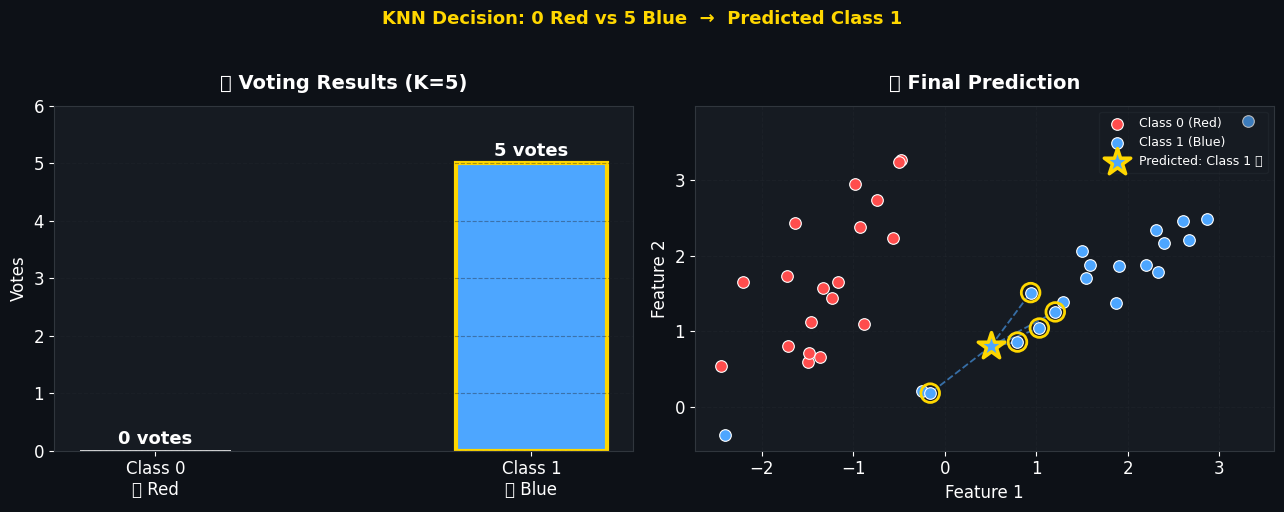


🏆 VERDICT: The mystery point is classified as → Class 1 🔵 (Blue)
   Votes: Red=0, Blue=5


In [15]:
from collections import Counter

# Count votes
vote_counts = Counter(k_nearest_classes)
predicted_class = vote_counts.most_common(1)[0][0]

# Bar chart of votes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Vote bar chart ──────────────────────────────────────
class_names = ['Class 0\n🔴 Red', 'Class 1\n🔵 Blue']
vote_values = [vote_counts.get(0, 0), vote_counts.get(1, 0)]
bar_colors = ['#ff4d4d', '#4da6ff']
bars = ax1.bar(class_names, vote_values, color=bar_colors, edgecolor='white',
               linewidth=1.2, width=0.4)

# Highlight the winner
winner_idx = 0 if predicted_class == 0 else 1
bars[winner_idx].set_edgecolor('#ffd700')
bars[winner_idx].set_linewidth(3)

for bar, val in zip(bars, vote_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val} vote{"s" if val != 1 else ""}', ha='center',
             va='bottom', fontweight='bold', fontsize=13)

ax1.set_ylim(0, K + 1)
ax1.set_title(f'🗳️ Voting Results (K={K})', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Votes')
ax1.grid(axis='y', alpha=0.4)

# ── Right: Final prediction plot ──────────────────────────────
ax2.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=70, edgecolors='white',
            linewidths=0.8, label='Class 0 (Red)', zorder=3)
ax2.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=70, edgecolors='white',
            linewidths=0.8, label='Class 1 (Blue)', zorder=3)

# Mystery point colored by prediction
pred_color = '#ff4d4d' if predicted_class == 0 else '#4da6ff'
pred_label = f'Predicted: Class {predicted_class} {"🔴" if predicted_class == 0 else "🔵"}'
ax2.scatter(*new_point, c=pred_color, s=400, marker='*', edgecolors='#ffd700',
            linewidths=2.5, label=pred_label, zorder=5)

# Draw K neighbor lines
for i, pt in enumerate(k_nearest_points):
    c = '#ff4d4d' if k_nearest_classes[i] == 0 else '#4da6ff'
    ax2.plot([new_point[0], pt[0]], [new_point[1], pt[1]],
             color=c, lw=1.3, alpha=0.6, linestyle='--', zorder=2)
    ax2.scatter(*pt, s=180, facecolors='none', edgecolors='#ffd700',
                linewidths=2, zorder=4)

ax2.set_title('✅ Final Prediction', fontsize=14, fontweight='bold', pad=12)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend(loc='upper right', framealpha=0.3, edgecolor='#30363d', fontsize=9)
ax2.grid(True)

plt.suptitle(f'KNN Decision: {vote_counts[0]} Red vs {vote_counts[1]} Blue  →  Predicted Class {predicted_class}',
             fontsize=13, color='#ffd700', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n🏆 VERDICT: The mystery point is classified as → Class {predicted_class} {'🔴 (Red)' if predicted_class == 0 else '🔵 (Blue)'}")
print(f"   Votes: Red={vote_counts.get(0,0)}, Blue={vote_counts.get(1,0)}")

## Section 7 — Effect of K on the Decision Boundary

The choice of K is the most critical hyperparameter in KNN. The four plots below compare K = 1, 3, 5, and 7 on the same dataset.

| K Value | Boundary Characteristic | Risk |
|---------|------------------------|------|
| Small K (e.g. K=1) | Highly irregular, complex boundary | Overfitting — sensitive to noise |
| Medium K | Balanced boundary | Good generalisation |
| Large K | Smooth, simple boundary | Underfitting — may miss local patterns |

**Practical guidance:** Use cross-validation to select the optimal K for your dataset rather than relying on a fixed default.

/var/folders/3m/9vv3h34125j5f4hqrzq2y76m0000gn/T/ipykernel_74198/880219692.py:38: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/nilesh/Desktop/untitled folder 6/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


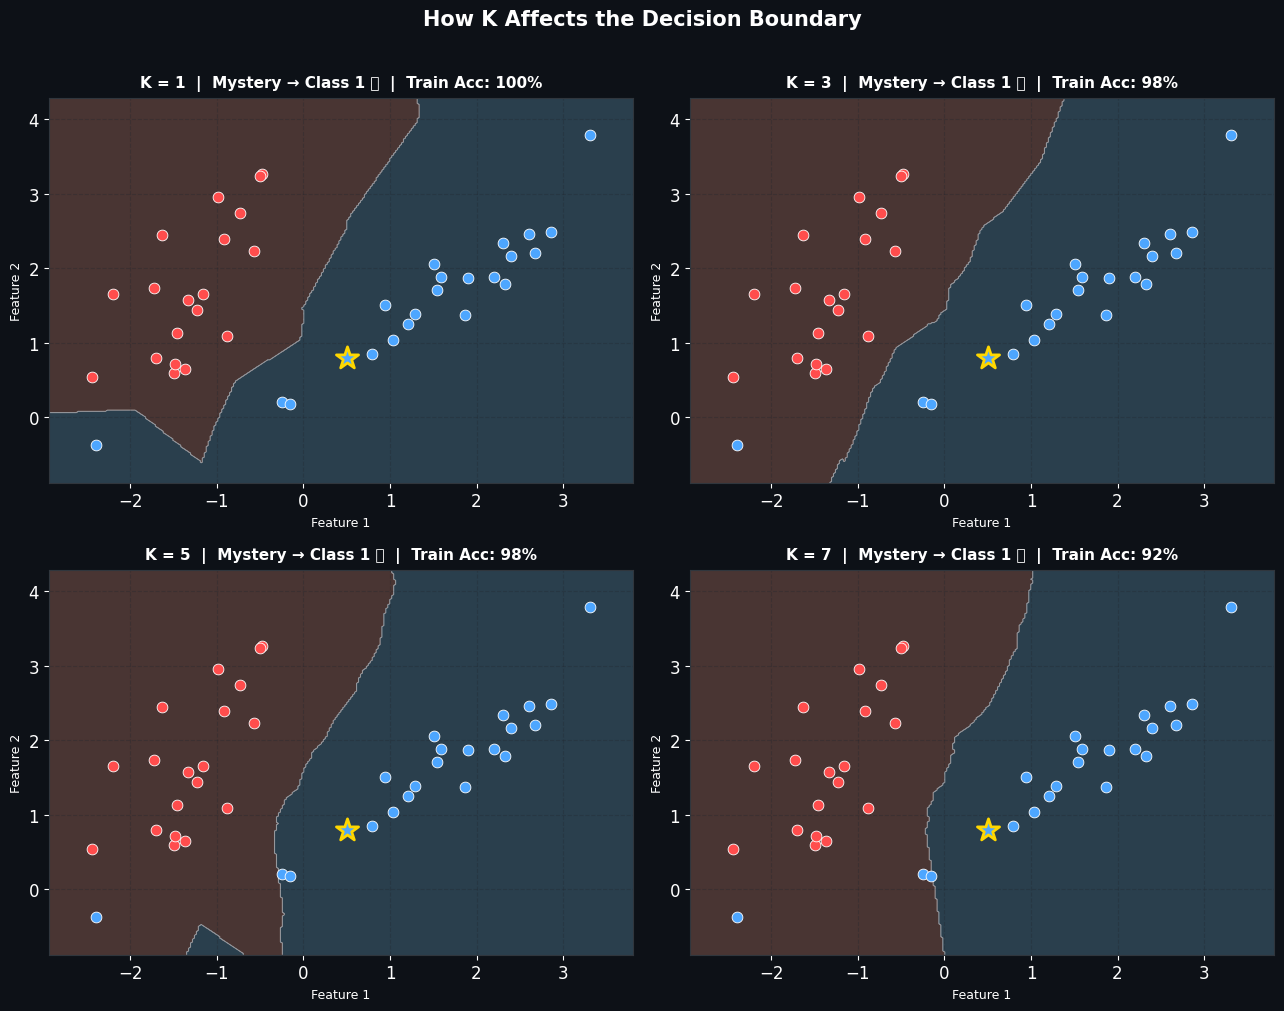


📊 Summary Table:
┌─────┬────────────────────┬─────────────────┐
│  K  │ Mystery Prediction │ Train Accuracy  │
├─────┼────────────────────┼─────────────────┤
│  1  │ Class 1 🔵          │     100%          │
│  3  │ Class 1 🔵          │     98%          │
│  5  │ Class 1 🔵          │     98%          │
│  7  │ Class 1 🔵          │     92%          │
└─────┴────────────────────┴─────────────────┘


In [16]:
k_values = [1, 3, 5, 7]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

for ax, k in zip(axes, k_values):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu', levels=[-0.5, 0.5, 1.5])
    ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.4, levels=[0.5])

    ax.scatter(X[y==0, 0], X[y==0, 1], c='#ff4d4d', s=60, edgecolors='white',
               linewidths=0.6, zorder=3)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='#4da6ff', s=60, edgecolors='white',
               linewidths=0.6, zorder=3)

    # Mystery point
    pred = clf.predict([new_point])[0]
    pt_color = '#ff4d4d' if pred == 0 else '#4da6ff'
    ax.scatter(*new_point, c=pt_color, s=280, marker='*', edgecolors='#ffd700',
               linewidths=2, zorder=5)

    acc = clf.score(X, y)
    ax.set_title(f'K = {k}  |  Mystery → Class {pred} {"🔴" if pred==0 else "🔵"}  |  Train Acc: {acc:.0%}',
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Feature 1', fontsize=9)
    ax.set_ylabel('Feature 2', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('How K Affects the Decision Boundary', fontsize=15,
             fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Summary Table:")
print("┌─────┬────────────────────┬─────────────────┐")
print("│  K  │ Mystery Prediction │ Train Accuracy  │")
print("├─────┼────────────────────┼─────────────────┤")
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)
    pred = clf.predict([new_point])[0]
    acc = clf.score(X, y)
    lbl = f"Class {pred} {'🔴' if pred==0 else '🔵'}"
    print(f"│  {k}  │ {lbl:<18} │     {acc:.0%}          │")
print("└─────┴────────────────────┴─────────────────┘")

---

## Summary

### Algorithm Steps

| Step | Operation |
|------|-----------|
| 1 | Store the entire labeled training dataset (no model is built) |
| 2 | Receive a new query point |
| 3 | Compute the distance from the query point to every training point |
| 4 | Select the K training points with the smallest distances |
| 5 | Count the class labels among those K neighbors |
| 6 | Assign the majority class as the predicted label |

### Key Properties

| Property | Detail |
|----------|--------|
| **Type** | Supervised, non-parametric, instance-based |
| **Training complexity** | O(1) — no training phase |
| **Prediction complexity** | O(n · d) — scales with dataset size and dimensionality |
| **Hyperparameter** | K (number of neighbors) |
| **Distance metrics** | Euclidean (default), Manhattan, Minkowski, cosine |
| **Common pitfalls** | Sensitive to feature scale — always normalise; slow on large datasets |

### When to Use KNN

- Baseline model for classification or regression tasks
- Small to medium-sized datasets where prediction latency is acceptable
- Problems where the decision boundary is irregular and non-linear

### Limitations

- Computationally expensive at prediction time for large datasets
- Degrades with high-dimensional data (curse of dimensionality)
- Requires feature scaling (standardisation or normalisation) before use